# Delivery Logistics & Route Performance Analysis

## 1. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand delivery patterns, route characteristics, operational performance, and potential bottlenecks in the logistics network.

### Key Business Questions

1. What does the overall logistics network look like?
2. How is actual delivery time distributed?
3. How does actual time compare with OSRM estimated time?
4. How does actual distance compare with OSRM estimated distance?
5. How do FTL and Carting routes differ in performance?
6. Which source and destination centers show unusual performance?
7. What operational factors are associated with longer delivery times?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Loading the Cleaned Dataset

The cleaned dataset produced during the data understanding and cleaning stage is loaded for exploratory analysis.

The raw dataset is not modified during EDA. Any new analytical variables created in this notebook will be added to the working DataFrame only.

In [3]:
df = pd.read_csv("../data/processed/delhivery_cleaned.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (144867, 24)


In [4]:
date_columns = [
    "trip_creation_time",
    "od_start_time",
    "od_end_time",
    "cutoff_timestamp"
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors="coerce")

print(df[date_columns].dtypes)

trip_creation_time    datetime64[ns]
od_start_time         datetime64[ns]
od_end_time           datetime64[ns]
cutoff_timestamp      datetime64[ns]
dtype: object


In [5]:
print("Rows:", len(df))
print("Unique trips:", df["trip_uuid"].nunique())

Rows: 144867
Unique trips: 14817


## 3. Overall Logistics Network

The first stage of EDA establishes a high-level view of the logistics network.

The analysis examines:

- Total logistics records
- Unique trips
- Source centers
- Destination centers
- Route types
- Training and test records

This provides context for the detailed performance analysis that follows.

In [6]:
overview = pd.Series({
    "Total Records": df.shape[0],
    "Unique Trips": df["trip_uuid"].nunique(),
    "Unique Source Centers": df["source_center"].nunique(),
    "Unique Destination Centers": df["destination_center"].nunique(),
    "Route Types": df["route_type"].nunique(),
    "Training Records": (df["data"] == "training").sum(),
    "Test Records": (df["data"] == "test").sum()
})

overview

Total Records                 144867
Unique Trips                   14817
Unique Source Centers           1508
Unique Destination Centers      1481
Route Types                        2
Training Records              104858
Test Records                   40009
dtype: int64

## 4. Route Type Distribution

The dataset contains two primary route types: `FTL` and `Carting`.

Understanding the distribution of these route types is important because delivery performance may vary depending on the logistics model used.

In [7]:
route_counts = df["route_type"].value_counts()

route_counts

route_type
FTL        99660
Carting    45207
Name: count, dtype: int64

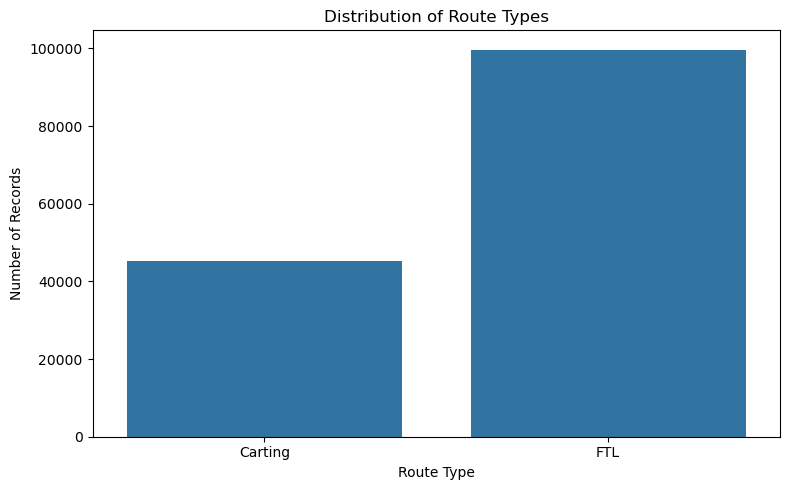

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="route_type"
)

plt.title("Distribution of Route Types")
plt.xlabel("Route Type")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()


### Observation

FTL accounts for the larger share of records, while Carting represents the smaller share.

This difference in volume should be considered when comparing performance between route types.

## 5. Actual Delivery Time Analysis

`actual_time` represents the observed time associated with the logistics movement.

Analyzing its distribution helps identify:

- Typical delivery time
- Variation in delivery time
- Potentially long-running movements
- Possible operational outliers

In [9]:
df["actual_time"].describe()

count    144867.000000
mean        416.927527
std         598.103621
min           9.000000
25%          51.000000
50%         132.000000
75%         513.000000
max        4532.000000
Name: actual_time, dtype: float64

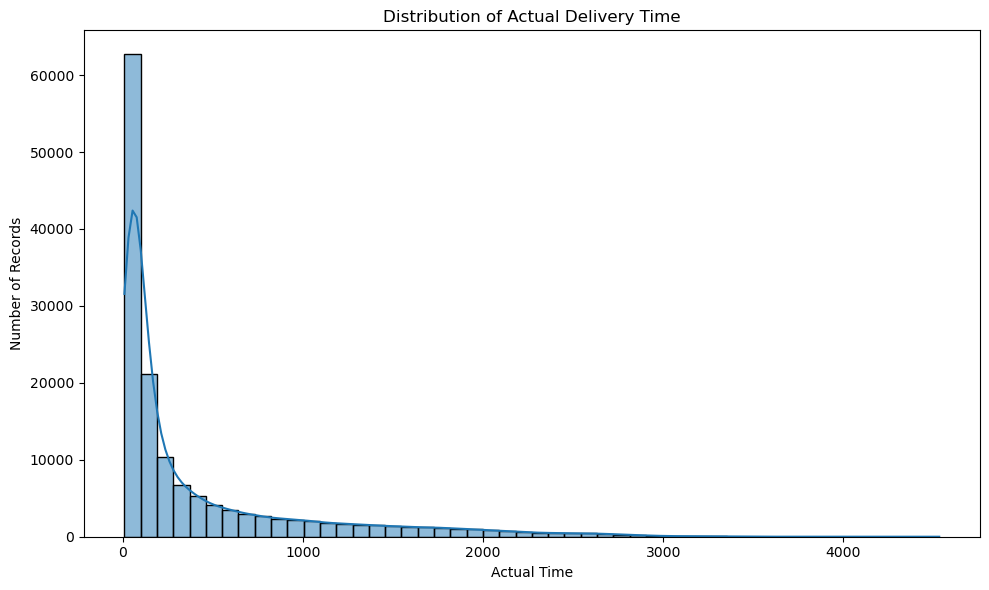

In [10]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="actual_time",
    bins=50,
    kde=True
)

plt.title("Distribution of Actual Delivery Time")
plt.xlabel("Actual Time")
plt.ylabel("Number of Records")

plt.tight_layout()
plt.show()

## 6. Actual Time vs OSRM Estimated Time

OSRM provides an estimated travel time, while `actual_time` represents the observed travel time.

Comparing these two measures helps identify differences between expected and observed travel performance.

A positive difference indicates that the observed time was greater than the OSRM estimate, while a negative difference indicates that the observed time was lower than the estimate.

In [11]:
# Create deviation
df["time_deviation"] = (
    df["actual_time"] - df["osrm_time"]
)

df["time_deviation"].describe()

count    144867.000000
mean        203.059254
std         303.743664
min        -110.000000
25%          21.000000
50%          65.000000
75%         247.000000
max        3137.000000
Name: time_deviation, dtype: float64

In [12]:
#KPI comparison
print("Average Actual Time:",
      round(df["actual_time"].mean(), 2))

print("Average OSRM Time:",
      round(df["osrm_time"].mean(), 2))

print("Average Time Deviation:",
      round(df["time_deviation"].mean(), 2))

Average Actual Time: 416.93
Average OSRM Time: 213.87
Average Time Deviation: 203.06


Visualization

Because we have 144K+ records, we'll sample only for visualization.

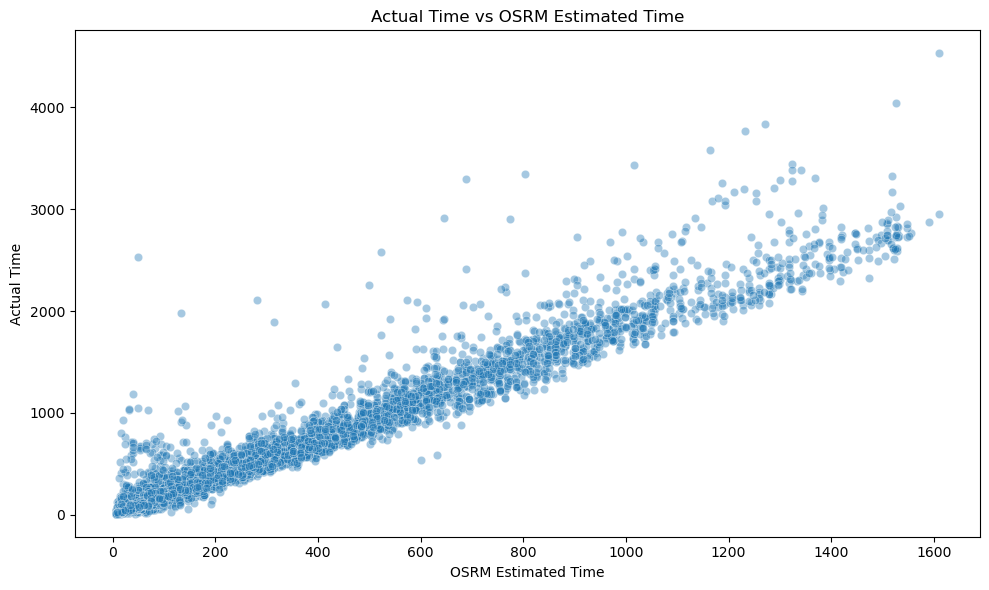

In [13]:
plot_sample = df.sample(
    n=min(10000, len(df)),
    random_state=42
)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=plot_sample,
    x="osrm_time",
    y="actual_time",
    alpha=0.4
)

plt.title("Actual Time vs OSRM Estimated Time")
plt.xlabel("OSRM Estimated Time")
plt.ylabel("Actual Time")

plt.tight_layout()
plt.show()

## 6.1 Investigating Time Anomalies

Before using `actual_time` and `time_deviation` for business conclusions, potentially anomalous values are examined.

Negative actual travel times and unusually large deviations may represent data-quality issues, segment-level measurements, or exceptional logistics movements.

The observations will be investigated before deciding whether they should be excluded from any specific analysis.


In [14]:
print("Negative actual_time records:",
      (df["actual_time"] < 0).sum())

print("Zero actual_time records:",
      (df["actual_time"] == 0).sum())

print("Negative OSRM time records:",
      (df["osrm_time"] < 0).sum())

Negative actual_time records: 0
Zero actual_time records: 0
Negative OSRM time records: 0


In [15]:
df[df["actual_time"] < 0][
    [
        "trip_uuid",
        "source_center",
        "destination_center",
        "actual_time",
        "osrm_time",
        "segment_actual_time",
        "segment_osrm_time"
    ]
].head(20)

,trip_uuid,source_center,destination_center,actual_time,osrm_time,segment_actual_time,segment_osrm_time


In [16]:
#check
df.nlargest(
    10,
    "time_deviation"
)[
    [
        "trip_uuid",
        "source_center",
        "destination_center",
        "actual_time",
        "osrm_time",
        "time_deviation",
        "actual_distance_to_destination",
        "osrm_distance"
    ]
]

,trip_uuid,source_center,destination_center,actual_time,osrm_time,time_deviation,actual_distance_to_destination,osrm_distance
79527,trip-153736469866480991,IND000000ACB,IND712311AAA,4152.0,1015.0,3137.0,1300.480089,1427.0313
43171,trip-153724675612503042,IND000000ACB,IND600056AAB,4532.0,1610.0,2922.0,1721.532629,2190.6314
43172,trip-153724675612503042,IND000000ACB,IND600056AAB,4532.0,1610.0,2922.0,1721.601595,2190.6314
79526,trip-153736469866480991,IND000000ACB,IND712311AAA,3908.0,1010.0,2898.0,1300.489196,1426.5927
79525,trip-153736469866480991,IND000000ACB,IND712311AAA,3880.0,990.0,2890.0,1276.644697,1400.5472
79524,trip-153736469866480991,IND000000ACB,IND712311AAA,3854.0,973.0,2881.0,1254.334355,1377.4674
79523,trip-153736469866480991,IND000000ACB,IND712311AAA,3802.0,949.0,2853.0,1233.415387,1343.6363
79522,trip-153736469866480991,IND000000ACB,IND712311AAA,3770.0,941.0,2829.0,1211.595378,1332.8825
79521,trip-153736469866480991,IND000000ACB,IND712311AAA,3734.0,908.0,2826.0,1188.187256,1286.1235
79520,trip-153736469866480991,IND000000ACB,IND712311AAA,3694.0,888.0,2806.0,1167.313810,1258.2614


### Data Quality Check — Time Variables

The time variables were checked for physically invalid values.

- `actual_time` contains no negative values.
- `actual_time` contains no zero values.
- `osrm_time` contains no negative values.

Therefore, no records are removed based on these checks.

The negative values observed in `time_deviation` are valid because they indicate that the actual time was lower than the OSRM estimated time.

## 6.2 Extreme Time Deviations

The time deviation ranges from -110 to 3,137.

Rather than removing extreme observations immediately, the highest deviations are examined together with their actual time, OSRM estimate, route, distance, and segment-level metrics.

This helps determine whether the observations represent genuine operational variation or potential data-quality issues.

In [17]:
high_deviation = df.nlargest(
    10,
    "time_deviation"
)[
    [
        "trip_uuid",
        "source_center",
        "destination_center",
        "route_type",
        "actual_time",
        "osrm_time",
        "time_deviation",
        "actual_distance_to_destination",
        "osrm_distance",
        "segment_actual_time",
        "segment_osrm_time"
    ]
]

high_deviation

,trip_uuid,source_center,destination_center,route_type,actual_time,osrm_time,time_deviation,actual_distance_to_destination,osrm_distance,segment_actual_time,segment_osrm_time
79527,trip-153736469866480991,IND000000ACB,IND712311AAA,FTL,4152.0,1015.0,3137.0,1300.480089,1427.0313,244.0,15.0
43171,trip-153724675612503042,IND000000ACB,IND600056AAB,FTL,4532.0,1610.0,2922.0,1721.532629,2190.6314,2032.0,232.0
43172,trip-153724675612503042,IND000000ACB,IND600056AAB,FTL,4532.0,1610.0,2922.0,1721.601595,2190.6314,0.0,0.0
79526,trip-153736469866480991,IND000000ACB,IND712311AAA,FTL,3908.0,1010.0,2898.0,1300.489196,1426.5927,27.0,19.0
79525,trip-153736469866480991,IND000000ACB,IND712311AAA,FTL,3880.0,990.0,2890.0,1276.644697,1400.5472,26.0,17.0
79524,trip-153736469866480991,IND000000ACB,IND712311AAA,FTL,3854.0,973.0,2881.0,1254.334355,1377.4674,52.0,24.0
79523,trip-153736469866480991,IND000000ACB,IND712311AAA,FTL,3802.0,949.0,2853.0,1233.415387,1343.6363,32.0,34.0
79522,trip-153736469866480991,IND000000ACB,IND712311AAA,FTL,3770.0,941.0,2829.0,1211.595378,1332.8825,35.0,33.0
79521,trip-153736469866480991,IND000000ACB,IND712311AAA,FTL,3734.0,908.0,2826.0,1188.187256,1286.1235,40.0,19.0
79520,trip-153736469866480991,IND000000ACB,IND712311AAA,FTL,3694.0,888.0,2806.0,1167.313810,1258.2614,54.0,17.0


Also calculate the proportion of records with actual time above OSRM

In [18]:
above_osrm = (df["time_deviation"] > 0).mean() * 100

print(
    f"Records where actual time exceeded OSRM time: "
    f"{above_osrm:.2f}%"
)

Records where actual time exceeded OSRM time: 97.84%


In [19]:
below_osrm = (df["time_deviation"] < 0).mean() * 100

print(
    f"Records where actual time was below OSRM time: "
    f"{below_osrm:.2f}%"
)

Records where actual time was below OSRM time: 1.77%


### Key Finding

The analysis shows that 97.84% of records have an actual travel time greater than the OSRM estimated time, while only 1.77% have an actual time below the OSRM estimate.

This indicates a substantial and systematic difference between observed and estimated travel times in the dataset.

However, this metric represents travel-time deviation rather than confirmed delivery lateness. Therefore, it should not be interpreted directly as an SLA or late-delivery rate.

In [20]:
#one small verification
equal_osrm = (df["time_deviation"] == 0).mean() * 100

print(f"Records where actual time equals OSRM time: {equal_osrm:.2f}%")

Records where actual time equals OSRM time: 0.38%


### Key Finding — Actual vs OSRM Time

A large majority of records (97.84%) have an actual travel time greater than the OSRM estimated time. Only 1.77% have an actual time below the OSRM estimate, while 0.38% have equal values.

This indicates a systematic difference between observed and estimated travel times. However, this comparison measures travel-time deviation and should not be interpreted as the actual delivery late rate.

## 7. Actual Distance vs OSRM Estimated Distance

The dataset contains both the actual distance to the destination and the distance estimated by OSRM.

Comparing these measures helps identify how closely the estimated route distance represents the observed logistics movement.

A positive distance deviation indicates that the actual distance is greater than the OSRM estimate.

In [21]:
df["distance_deviation"] = (
    df["actual_distance_to_destination"] - df["osrm_distance"]
)

df["distance_deviation"].describe()

count    144867.000000
mean        -50.697925
std          81.388901
min        -469.458566
25%         -54.992652
50%         -14.802877
75%          -4.790011
max           0.230174
Name: distance_deviation, dtype: float64

create a distance ratio

In [22]:
df["distance_ratio"] = np.where(
    df["osrm_distance"] != 0,
    df["actual_distance_to_destination"] / df["osrm_distance"],
    np.nan
)

df["distance_ratio"].describe()

count    144867.000000
mean          0.817341
std           0.101470
min           0.096352
25%           0.770827
50%           0.830672
75%           0.884273
max           1.023299
Name: distance_ratio, dtype: float64

basic camparison


In [23]:
print(
    "Average Actual Distance:",
    round(df["actual_distance_to_destination"].mean(), 2)
)

print(
    "Average OSRM Distance:",
    round(df["osrm_distance"].mean(), 2)
)

print(
    "Average Distance Deviation:",
    round(df["distance_deviation"].mean(), 2)
)

Average Actual Distance: 234.07
Average OSRM Distance: 284.77
Average Distance Deviation: -50.7


check direction of variation

In [24]:
print(
    "Actual distance > OSRM:",
    round((df["distance_deviation"] > 0).mean() * 100, 2),
    "%"
)

print(
    "Actual distance < OSRM:",
    round((df["distance_deviation"] < 0).mean() * 100, 2),
    "%"
)

print(
    "Actual distance = OSRM:",
    round((df["distance_deviation"] == 0).mean() * 100, 2),
    "%"
)

Actual distance > OSRM: 0.0 %
Actual distance < OSRM: 100.0 %
Actual distance = OSRM: 0.0 %


Visualization

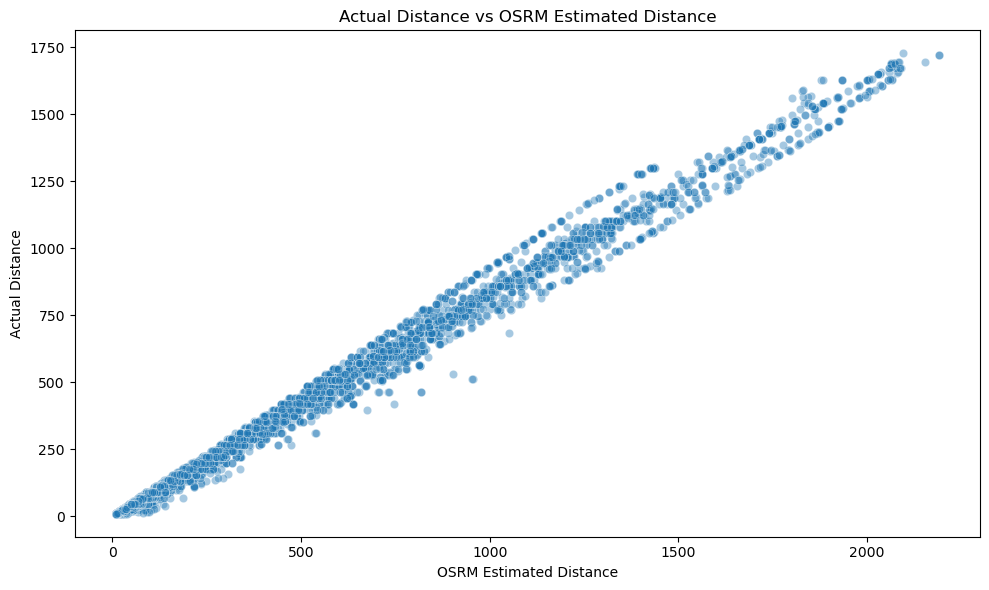

In [25]:
plot_sample = df.sample(
    n=min(10000, len(df)),
    random_state=42
)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=plot_sample,
    x="osrm_distance",
    y="actual_distance_to_destination",
    alpha=0.4
)

plt.title("Actual Distance vs OSRM Estimated Distance")
plt.xlabel("OSRM Estimated Distance")
plt.ylabel("Actual Distance")

plt.tight_layout()
plt.show()

### Key Finding — Actual vs OSRM Distance

Actual distance is consistently lower than OSRM estimated distance across the dataset.

The average actual distance is 234.07, compared with an average OSRM distance of 284.77. The average distance deviation is -50.70, and the average actual-to-OSRM distance ratio is approximately 0.817.

All observed records have an actual distance lower than the OSRM distance.

This indicates that OSRM generally provides a higher distance estimate than the actual distance represented in the logistics records. This difference should be considered when evaluating route-estimation performance.

## 8. Route Type Performance — FTL vs Carting

FTL (Full Truck Load) and Carting represent the two route types in the dataset.

This analysis compares their operational performance using travel time, estimated time, distance, and time deviation.

The objective is to determine whether route type is associated with differences in logistics performance.

In [26]:
route_performance = (
    df.groupby("route_type")
      .agg(
          records=("trip_uuid", "size"),
          unique_trips=("trip_uuid", "nunique"),
          avg_actual_time=("actual_time", "mean"),
          avg_osrm_time=("osrm_time", "mean"),
          avg_time_deviation=("time_deviation", "mean"),
          avg_actual_distance=("actual_distance_to_destination", "mean"),
          avg_osrm_distance=("osrm_distance", "mean")
      )
      .round(2)
)

route_performance

,records,unique_trips,avg_actual_time,avg_osrm_time,avg_time_deviation,avg_actual_distance,avg_osrm_distance
route_type,,,,,,,
Carting,45207,8908,70.64,30.45,40.19,26.62,34.31
FTL,99660,5909,574.01,297.07,276.94,328.18,398.38


In [27]:
#add percentage difference 
route_performance["time_deviation_pct"] = (
    route_performance["avg_time_deviation"]
    / route_performance["avg_osrm_time"]
    * 100
).round(2)

route_performance

,records,unique_trips,avg_actual_time,avg_osrm_time,avg_time_deviation,avg_actual_distance,avg_osrm_distance,time_deviation_pct
route_type,,,,,,,,
Carting,45207,8908,70.64,30.45,40.19,26.62,34.31,131.99
FTL,99660,5909,574.01,297.07,276.94,328.18,398.38,93.22


Visualization 1- Actual Time

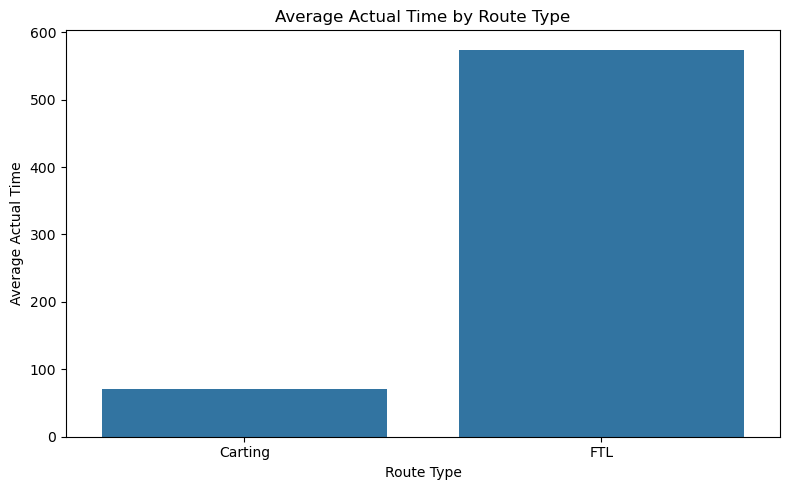

In [28]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="route_type",
    y="actual_time",
    estimator="mean",
    errorbar=None
)

plt.title("Average Actual Time by Route Type")
plt.xlabel("Route Type")
plt.ylabel("Average Actual Time")

plt.tight_layout()
plt.show()

Visualization 2-  Time deviation

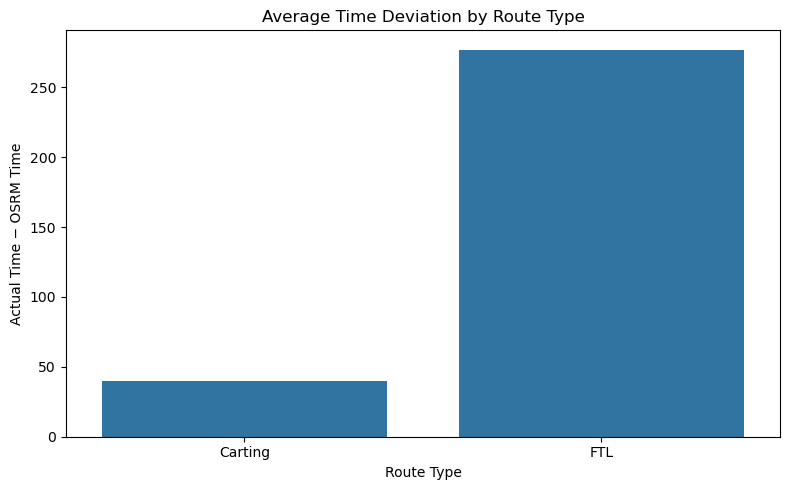

In [29]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="route_type",
    y="time_deviation",
    estimator="mean",
    errorbar=None
)

plt.title("Average Time Deviation by Route Type")
plt.xlabel("Route Type")
plt.ylabel("Actual Time − OSRM Time")

plt.tight_layout()
plt.show()

### Key Findings — FTL vs Carting

FTL and Carting show substantially different operational characteristics.

FTL has much higher average actual travel time and distance than Carting. Its average time deviation is also considerably larger in absolute terms.

However, when time deviation is normalized relative to OSRM estimated time, Carting shows a higher relative deviation (131.99%) compared with FTL (93.22%).

Therefore, absolute deviation and relative deviation provide different perspectives. FTL has the larger absolute time gap, while Carting has the larger proportional gap relative to its estimated travel time.

The difference in unique trips and records also indicates that the two route types may have different segment structures, which should be investigated further.

*8.1*Segments per Trip
## 8.1 Trip Segmentation by Route Type

The dataset contains multiple records for the same `trip_uuid`.

To understand the structure of the logistics network, we calculate the average number of records (segments) associated with each trip for FTL and Carting.

This helps explain why the number of records and unique trips differ between the two route types.

In [30]:
segments_per_trip = (
    df.groupby(["route_type", "trip_uuid"])
      .size()
      .reset_index(name="segments")
)

segments_summary = (
    segments_per_trip
    .groupby("route_type")["segments"]
    .agg(
        avg_segments="mean",
        median_segments="median",
        max_segments="max"
    )
    .round(2)
)

segments_summary

,avg_segments,median_segments,max_segments
route_type,,,
Carting,5.07,4.0,49
FTL,16.87,10.0,101


Then calculate the overall distribution:

In [31]:
segments_summary_all = (
    df.groupby("trip_uuid")
      .size()
      .describe()
)

segments_summary_all

count    14817.000000
mean         9.777080
std         13.596444
min          1.000000
25%          3.000000
50%          5.000000
75%         10.000000
max        101.000000
dtype: float64

### Key Finding — Trip Segmentation

FTL trips contain substantially more segment records than Carting trips.

The average number of segments per trip is 16.87 for FTL compared with 5.07 for Carting. The median is 10 segments for FTL and 4 segments for Carting.

Combined with the earlier time and distance analysis, this indicates that FTL trips in the dataset are generally represented by larger and more segmented logistics movements, while Carting trips involve fewer segments and shorter movements on average.

9. Source & Destination Center Analysis

## 9. Source Center Performance Analysis

Logistics performance may vary across source centers because of differences in route characteristics, processing conditions, and network structure.

This analysis aggregates records by source center and evaluates:

- Number of records
- Number of unique trips
- Average actual time
- Average OSRM time
- Average time deviation

Centers with consistently high time deviations may warrant further operational investigation.

In [32]:
source_performance = (
    df.groupby(["source_center", "source_name"])
      .agg(
          records=("trip_uuid", "size"),
          unique_trips=("trip_uuid", "nunique"),
          avg_actual_time=("actual_time", "mean"),
          avg_osrm_time=("osrm_time", "mean"),
          avg_time_deviation=("time_deviation", "mean")
      )
      .reset_index()
)

source_performance["time_deviation_pct"] = (
    source_performance["avg_time_deviation"]
    / source_performance["avg_osrm_time"]
    * 100
)

source_performance = source_performance.round(2)

source_performance.head()

,source_center,source_name,records,unique_trips,avg_actual_time,avg_osrm_time,avg_time_deviation,time_deviation_pct
0,IND000000AAL,Pune_PC (Maharashtra),37,18,63.70,22.22,41.49,186.74
1,IND000000AAQ,Barasat_KrshnNgr_D (West Bengal),4,2,78.25,12.50,65.75,526.00
2,IND000000AAS,Bongaigaon_Chpaguri_D (Assam),18,9,50.56,25.89,24.67,95.28
3,IND000000AAZ,Buldhana_Thsil3PL_D (Maharashtra),6,2,152.00,36.00,116.00,322.22
4,IND000000ABA,Cochin_Chtrpuza_D (Kerala),13,7,30.85,19.31,11.54,59.76


In [33]:
source_performance["records"].describe()

count     1508.000000
mean        96.065650
std        728.748699
min          1.000000
25%         11.750000
50%         27.000000
75%         50.250000
max      23347.000000
Name: records, dtype: float64

In [34]:
source_filtered = source_performance[
    source_performance["records"] >= 100
].copy()

9.1 — Choose a Minimum Record Threshold

## 9.1 Minimum Record Threshold for Center Analysis

Source centers have highly unequal numbers of observations. Some centers contain thousands of records, while others contain only a few.

To avoid ranking centers based on insufficient observations, different minimum-record thresholds are evaluated before selecting a threshold for performance comparison.

In [35]:
thresholds = [10, 25, 50, 100, 250]

threshold_check = pd.DataFrame({
    "Minimum Records": thresholds,
    "Centers Remaining": [
        (source_performance["records"] >= t).sum()
        for t in thresholds
    ]
})

threshold_check

,Minimum Records,Centers Remaining
0,10,1165
1,25,811
2,50,387
3,100,160
4,250,56


In [36]:
MIN_RECORDS = 50

source_filtered = source_performance[
    source_performance["records"] >= MIN_RECORDS
].copy()

print("Source centers included:", len(source_filtered))

Source centers included: 387


### Selecting a Minimum Record Threshold

Source centers have highly uneven observation volumes, ranging from 1 to 23,347 records.

A minimum threshold of 50 records is selected for center-level performance comparisons. This removes very low-volume centers while retaining 387 source centers for analysis.

The threshold is used to reduce the influence of unstable averages caused by very small sample sizes.

Now we'll rank the 387 sufficiently represented source centers by time deviation.

In [37]:
top_source_deviation = (
    source_filtered
    .sort_values("avg_time_deviation", ascending=False)
    .head(10)
)

top_source_deviation[
    [
        "source_center",
        "source_name",
        "records",
        "unique_trips",
        "avg_actual_time",
        "avg_osrm_time",
        "avg_time_deviation",
        "time_deviation_pct"
    ]
]

,source_center,source_name,records,unique_trips,avg_actual_time,avg_osrm_time,avg_time_deviation,time_deviation_pct
1360,IND781018AAB,Guwahati_Hub (Assam),1568,90,1335.66,526.78,808.88,153.55
218,IND212402AAA,Phulpur_Shekhpur_D (Uttar Pradesh),65,13,819.11,22.60,796.51,3524.37
602,IND416606AAA,Malvan_BllvMarg_D (Maharashtra),50,10,785.46,29.40,756.06,2571.63
922,IND562132AAC,Bengaluru_Nelmngla_L (Karnataka),78,1,1489.64,841.94,647.71,76.93
1488,IND847226AAA,Jaynagar_Wardno6_D (Bihar),105,21,566.73,57.70,509.03,882.13
1505,IND854326AAB,Purnia_Central_H_2 (Bihar),1053,70,881.30,418.79,462.51,110.44
1312,IND751002AAB,Bhubaneshwar_Hub (Orissa),1469,79,820.60,359.33,461.26,128.37
8,IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),23347,1063,902.85,481.81,421.04,87.39
921,IND562132AAA,Bangalore_Nelmngla_H (Karnataka),9975,768,904.70,493.35,411.35,83.38
1224,IND712311AAA,Kolkata_Dankuni_HB (West Bengal),2612,262,697.42,321.23,376.20,117.11


In [38]:
#also the lowest
bottom_source_deviation = (
    source_filtered
    .sort_values("avg_time_deviation", ascending=True)
    .head(10)
)

bottom_source_deviation[
    [
        "source_center",
        "source_name",
        "records",
        "unique_trips",
        "avg_actual_time",
        "avg_osrm_time",
        "avg_time_deviation",
        "time_deviation_pct"
    ]
]

,source_center,source_name,records,unique_trips,avg_actual_time,avg_osrm_time,avg_time_deviation,time_deviation_pct
251,IND244235AAA,Gajraula_JawaharN_D (Uttar Pradesh),80,20,72.56,88.19,-15.62,-17.72
138,IND160055AAA,Chandigarh_Mohali (Chandigarh),76,21,31.91,28.51,3.39,11.91
1069,IND614715AAA,Thirthurpondi_Madaprum_D (Tamil Nadu),51,17,38.61,33.67,4.94,14.68
1109,IND628204AAA,Tirchchndr_Shnmgprm_D (Tamil Nadu),68,17,32.79,27.22,5.57,20.48
76,IND131021AAA,Sonipat_AmzonDev_V (Haryana),111,58,16.21,9.99,6.22,62.22
1150,IND642126AAA,Udumalpet_Artclgrd_D (Tamil Nadu),65,17,29.68,22.26,7.42,33.31
181,IND201307AAA,Noida_Chukhndi_D (Uttar Pradesh),58,28,25.26,17.47,7.79,44.62
1126,IND636016AAA,Salem (Tamil Nadu),81,16,42.53,34.62,7.91,22.86
1137,IND638657AAA,Dharapuram_Techrcly_D (Tamil Nadu),63,16,30.48,21.60,8.87,41.07
733,IND495334AAB,Mungeli_Panderia_D (Chhattisgarh),59,12,45.78,36.83,8.95,24.30


## 9.2 Source Center Performance — Key Findings

After applying a minimum threshold of 50 records per source center, 387 source centers were retained for comparison.

The largest average absolute time deviations were observed at Guwahati Hub, Phulpur Shekhpur D, Malvan BllvMarg D, Bengaluru Nelmngla L, and Jaynagar Wardno6 D.

Guwahati Hub is particularly notable because its high deviation is supported by a relatively large observation volume (1,568 records across 90 trips).

Percentage deviation should be interpreted carefully because centers with very small average OSRM times can produce extremely high percentages even when their absolute deviation is comparatively moderate.

Therefore, absolute time deviation and observation volume are used as the primary indicators, with percentage deviation providing additional context.

In [39]:
top_source_volume = (
    source_filtered
    .sort_values("records", ascending=False)
    .head(10)
)

top_source_volume[
    [
        "source_center",
        "source_name",
        "records",
        "unique_trips",
        "avg_actual_time",
        "avg_osrm_time",
        "avg_time_deviation",
        "time_deviation_pct"
    ]
]

,source_center,source_name,records,unique_trips,avg_actual_time,avg_osrm_time,avg_time_deviation,time_deviation_pct
8,IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),23347,1063,902.85,481.81,421.04,87.39
921,IND562132AAA,Bangalore_Nelmngla_H (Karnataka),9975,768,904.70,493.35,411.35,83.38
605,IND421302AAG,Bhiwandi_Mankoli_HB (Maharashtra),9088,821,684.50,345.41,339.09,98.17
568,IND411033AAA,Pune_Tathawde_H (Maharashtra),4061,403,454.22,256.19,198.03,77.30
753,IND501359AAE,Hyderabad_Shamshbd_H (Telangana),3340,329,412.51,206.01,206.50,100.24
1224,IND712311AAA,Kolkata_Dankuni_HB (West Bengal),2612,262,697.42,321.23,376.20,117.11
136,IND160002AAC,Chandigarh_Mehmdpur_H (Punjab),2450,370,254.57,130.62,123.95,94.90
512,IND395023AAA,Surat_HUB (Gujarat),2189,93,675.71,368.51,307.20,83.36
28,IND110037AAM,Delhi_Airport_H (Delhi),2013,256,593.79,288.96,304.83,105.49
908,IND560099AAB,Bengaluru_Bomsndra_HB (Karnataka),1958,466,99.79,58.85,40.95,69.58


### Key Finding — High-Volume Source Centers

High-volume source centers show substantial differences between actual and OSRM estimated travel times.

Gurgaon_Bilaspur_HB has the highest record volume in the dataset (23,347 records across 1,063 trips) and an average time deviation of 421.04.

Other high-volume centers, including Bangalore_Nelmngla_H, Bhiwandi_Mankoli_HB, Kolkata_Dankuni_HB, Surat_HUB, and Delhi_Airport_H, also show substantial positive time deviations.

These centers are particularly relevant for operational analysis because performance issues at high-volume locations may have greater potential business impact than similar deviations at very low-volume centers.

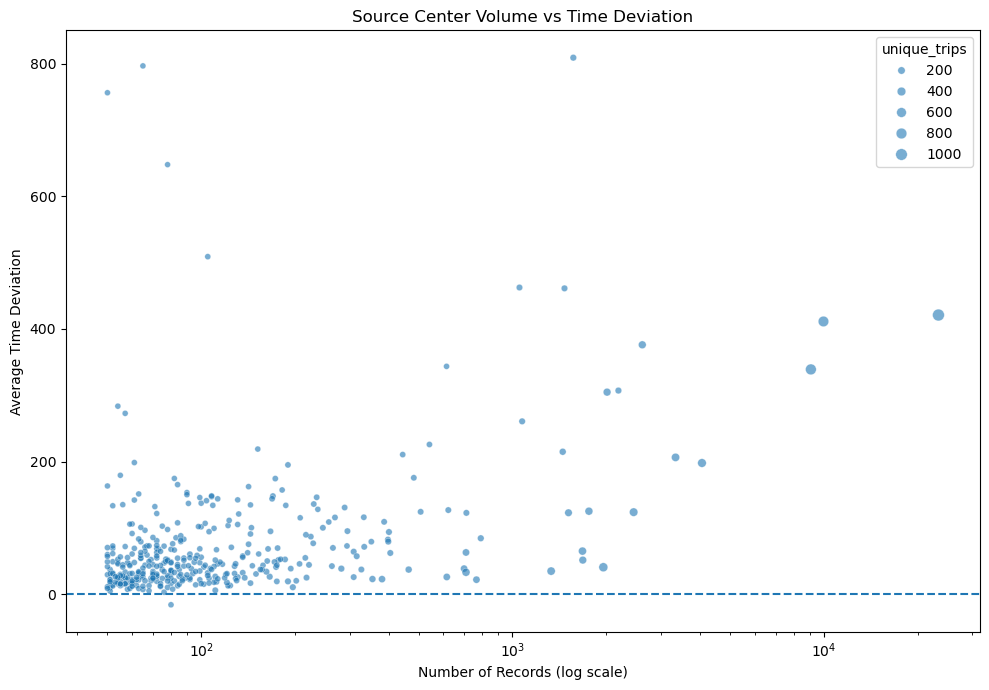

In [40]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=source_filtered,
    x="records",
    y="avg_time_deviation",
    size="unique_trips",
    alpha=0.6
)

plt.xscale("log")
plt.axhline(0, linestyle="--")

plt.title("Source Center Volume vs Time Deviation")
plt.xlabel("Number of Records (log scale)")
plt.ylabel("Average Time Deviation")

plt.tight_layout()
plt.show()

### Key Finding — Source Center Volume vs Time Deviation

The source-center analysis shows substantial variation in both observation volume and average time deviation.

Most centers have relatively low record volumes and moderate time deviations, while a smaller number of centers exhibit substantially higher deviations.

High-volume centers with large positive time deviations are particularly relevant for operational investigation because their performance differences affect a larger number of logistics records.

The analysis therefore suggests that source-center performance should be evaluated using both operational volume and time deviation rather than deviation alone.

9.3 Destination Center Analysis

## 9.3 Destination Center Performance Analysis

Destination centers represent the receiving side of the logistics network.

This analysis evaluates destination-center performance using:

- Number of records
- Number of unique trips
- Average actual time
- Average OSRM time
- Average time deviation

The objective is to identify destination centers associated with relatively high or low travel-time deviations.

In [41]:
destination_performance = (
    df.groupby(["destination_center", "destination_name"])
      .agg(
          records=("trip_uuid", "size"),
          unique_trips=("trip_uuid", "nunique"),
          avg_actual_time=("actual_time", "mean"),
          avg_osrm_time=("osrm_time", "mean"),
          avg_time_deviation=("time_deviation", "mean")
      )
      .reset_index()
)

destination_performance["time_deviation_pct"] = (
    destination_performance["avg_time_deviation"]
    / destination_performance["avg_osrm_time"]
    * 100
)

destination_performance = destination_performance.round(2)

destination_performance["records"].describe()

count     1481.000000
mean        97.817016
std        587.904111
min          1.000000
25%         10.000000
50%         26.000000
75%         50.000000
max      15192.000000
Name: records, dtype: float64

In [42]:
#check threshold
threshold_check_destination = pd.DataFrame({
    "Minimum Records": [10, 25, 50, 100, 250],
    "Centers Remaining": [
        (destination_performance["records"] >= t).sum()
        for t in [10, 25, 50, 100, 250]
    ]
})

threshold_check_destination

,Minimum Records,Centers Remaining
0,10,1142
1,25,782
2,50,376
3,100,169
4,250,65


In [43]:
MIN_RECORDS = 50

destination_filtered = destination_performance[
    destination_performance["records"] >= MIN_RECORDS
].copy()

print(
    "Destination centers included:",
    len(destination_filtered)
)

Destination centers included: 376


Highest destination deviations

In [44]:
top_destination_deviation = (
    destination_filtered
    .sort_values("avg_time_deviation", ascending=False)
    .head(10)
)

top_destination_deviation[
    [
        "destination_center",
        "destination_name",
        "records",
        "unique_trips",
        "avg_actual_time",
        "avg_osrm_time",
        "avg_time_deviation",
        "time_deviation_pct"
    ]
]

,destination_center,destination_name,records,unique_trips,avg_actual_time,avg_osrm_time,avg_time_deviation,time_deviation_pct
595,IND416510AAA,Sawantwadi_LaxmiNgr_D (Maharashtra),65,14,635.06,35.98,599.08,1664.81
1205,IND712311AAA,Kolkata_Dankuni_HB (West Bengal),4892,219,1039.58,471.65,567.92,120.41
25,IND110037AAM,Delhi_Airport_H (Delhi),3769,189,992.21,443.38,548.83,123.78
846,IND521225AAB,Vijayawada_Rynapadu_H (Andhra Pradesh),1200,61,944.74,490.08,454.66,92.77
1295,IND751002AAB,Bhubaneshwar_Hub (Orissa),2524,85,898.88,456.35,442.53,96.97
340,IND302014AAA,Jaipur_Hub (Rajasthan),1700,96,894.70,452.39,442.31,97.77
1435,IND834002AAB,Ranchi_Hub (Jharkhand),1307,66,822.08,391.58,430.50,109.94
1335,IND781018AAB,Guwahati_Hub (Assam),674,90,650.43,241.54,408.89,169.28
911,IND562132AAA,Bangalore_Nelmngla_H (Karnataka),11019,665,911.30,510.20,401.09,78.61
669,IND462022AAA,Bhopal_Trnsport_H (Madhya Pradesh),2264,143,717.63,347.85,369.78,106.30


Lowest destination deviations

In [45]:
bottom_destination_deviation = (
    destination_filtered
    .sort_values("avg_time_deviation", ascending=True)
    .head(10)
)

bottom_destination_deviation[
    [
        "destination_center",
        "destination_name",
        "records",
        "unique_trips",
        "avg_actual_time",
        "avg_osrm_time",
        "avg_time_deviation",
        "time_deviation_pct"
    ]
]

,destination_center,destination_name,records,unique_trips,avg_actual_time,avg_osrm_time,avg_time_deviation,time_deviation_pct
199,IND209206AAB,Ghatampur_StatinRD_D (Uttar Pradesh),69,18,33.75,34.30,-0.55,-1.61
1058,IND614809AAA,Pushpavanam_Thmpulam_D (Tamil Nadu),51,17,38.61,33.67,4.94,14.68
1091,IND627657AAA,Thisayanvilai_UdnkdiRD_D (Tamil Nadu),68,17,32.79,27.22,5.57,20.48
1116,IND637211AAA,Tirchngode_Mhdhvpur_D (Tamil Nadu),75,15,40.40,34.21,6.19,18.08
78,IND131028AAA,Sonipat_Kundli_P (Haryana),111,58,16.21,9.99,6.22,62.22
1182,IND691506AAA,Kottarakkara_Amankovl_D (Kerala),62,21,25.73,19.11,6.61,34.60
413,IND335701AAA,Anupgarh_PrmNrDPP_D (Rajasthan),51,11,36.51,29.00,7.51,25.90
138,IND160055AAA,Chandigarh_Mohali (Chandigarh),103,36,31.09,23.56,7.52,31.93
174,IND201301AAL,Dadri_ICDCant_D (Uttar Pradesh),60,29,25.28,17.52,7.77,44.34
1132,IND642001AAA,Pollachi_Venkatsa_DC (Tamil Nadu),71,18,31.25,23.17,8.08,34.89


High-volume destination centers

In [46]:
top_destination_volume = (
    destination_filtered
    .sort_values("records", ascending=False)
    .head(10)
)

top_destination_volume[
    [
        "destination_center",
        "destination_name",
        "records",
        "unique_trips",
        "avg_actual_time",
        "avg_osrm_time",
        "avg_time_deviation",
        "time_deviation_pct"
    ]
]

,destination_center,destination_name,records,unique_trips,avg_actual_time,avg_osrm_time,avg_time_deviation,time_deviation_pct
6,IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),15192,928,747.77,408.71,339.06,82.96
911,IND562132AAA,Bangalore_Nelmngla_H (Karnataka),11019,665,911.30,510.20,401.09,78.61
601,IND421302AAG,Bhiwandi_Mankoli_HB (Maharashtra),5492,583,677.54,335.85,341.69,101.74
747,IND501359AAE,Hyderabad_Shamshbd_H (Telangana),5142,405,571.76,310.20,261.56,84.32
1205,IND712311AAA,Kolkata_Dankuni_HB (West Bengal),4892,219,1039.58,471.65,567.92,120.41
25,IND110037AAM,Delhi_Airport_H (Delhi),3769,189,992.21,443.38,548.83,123.78
563,IND411033AAA,Pune_Tathawde_H (Maharashtra),3695,330,515.73,281.47,234.26,83.23
135,IND160002AAC,Chandigarh_Mehmdpur_H (Punjab),2874,431,183.90,89.79,94.10,104.80
79,IND131028AAB,Sonipat_Kundli_H (Haryana),2796,329,370.35,194.37,175.98,90.54
1295,IND751002AAB,Bhubaneshwar_Hub (Orissa),2524,85,898.88,456.35,442.53,96.97


## 9.4 Destination Center Performance — Key Findings

After applying a minimum threshold of 50 records, destination centers were compared using average actual time, OSRM estimated time, and time deviation.

Several destination centers show substantially higher actual travel times than their OSRM estimates. Kolkata_Dankuni_HB, Delhi_Airport_H, Vijayawada_Rynapadu_H, and Bhubaneshwar_Hub are notable high-volume centers with large positive time deviations.

Kolkata_Dankuni_HB is particularly important because it combines a high average time deviation of 567.92 with 4,892 records.

High-volume destination centers with large positive deviations should be considered potential candidates for further operational investigation. However, the analysis identifies associations rather than proving that a destination center directly causes delays.

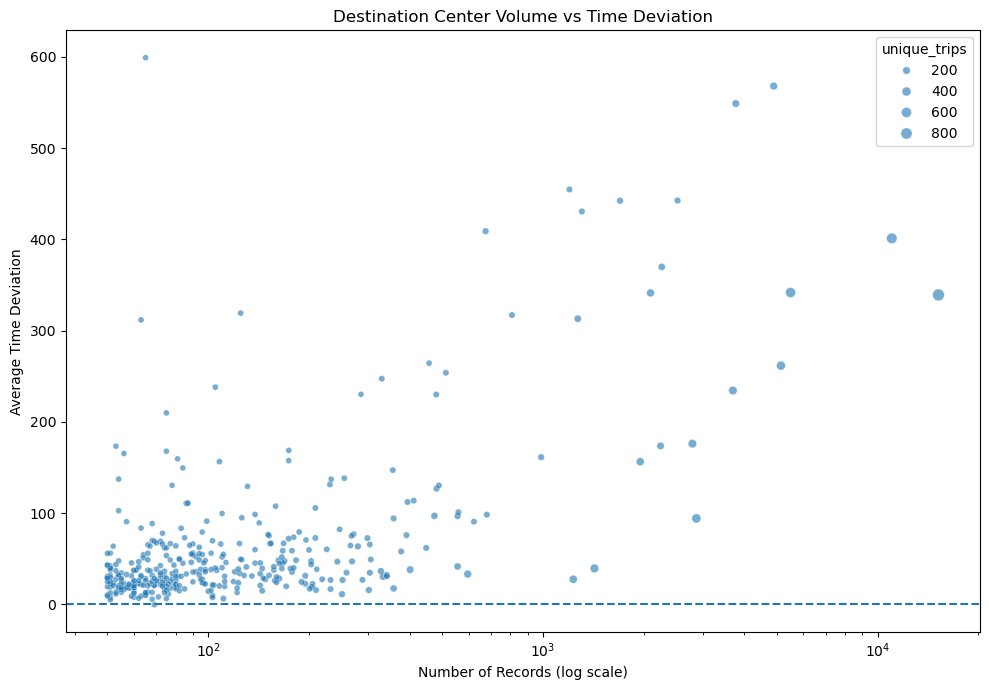

In [47]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=destination_filtered,
    x="records",
    y="avg_time_deviation",
    size="unique_trips",
    alpha=0.6
)

plt.xscale("log")
plt.axhline(0, linestyle="--")

plt.title("Destination Center Volume vs Time Deviation")
plt.xlabel("Number of Records (log scale)")
plt.ylabel("Average Time Deviation")

plt.tight_layout()
plt.show()

### Key Finding — Destination Center Volume vs Time Deviation

Destination centers show substantial variation in both operational volume and time deviation.

Most destination centers have relatively low record volumes and moderate positive time deviations, while a smaller group shows substantially larger deviations.

Several high-volume destination centers also exhibit large positive time deviations. These centers are potentially more important for operational investigation because the observed deviation occurs across a larger number of records.

Therefore, destination-center performance should be evaluated using both operational volume and time deviation rather than deviation alone.

Route-Level Analysis

## 10. Route-Level Performance Analysis

Individual source and destination centers provide useful information, but logistics performance also depends on the specific connection between two centers.

This analysis evaluates source-to-destination routes using:

- Number of records
- Number of unique trips
- Average actual time
- Average OSRM time
- Average time deviation
- Relative time deviation

The objective is to identify frequently used routes with substantial differences between actual and estimated travel time.

In [48]:
route_performance = (
    df.groupby(
        ["source_center", "source_name",
         "destination_center", "destination_name"]
    )
    .agg(
        records=("trip_uuid", "size"),
        unique_trips=("trip_uuid", "nunique"),
        avg_actual_time=("actual_time", "mean"),
        avg_osrm_time=("osrm_time", "mean"),
        avg_time_deviation=("time_deviation", "mean")
    )
    .reset_index()
)

route_performance["time_deviation_pct"] = (
    route_performance["avg_time_deviation"]
    / route_performance["avg_osrm_time"]
    * 100
)

route_performance = route_performance.round(2)

route_performance.shape

(2783, 10)

Check route volume distribution

In [49]:
route_performance["records"].describe()

count    2783.000000
mean       52.054258
std       167.682747
min         1.000000
25%         6.000000
50%        20.000000
75%        44.000000
max      4976.000000
Name: records, dtype: float64

In [50]:
route_thresholds = [5, 10, 25, 50, 100]

route_threshold_check = pd.DataFrame({
    "Minimum Records": route_thresholds,
    "Routes Remaining": [
        (route_performance["records"] >= t).sum()
        for t in route_thresholds
    ]
})

route_threshold_check

,Minimum Records,Routes Remaining
0,5,2203
1,10,1825
2,25,1208
3,50,611
4,100,260


### Selecting a Minimum Record Threshold for Route Analysis

The 2,783 source-to-destination routes have highly uneven observation volumes, ranging from 1 to 4,976 records.

A minimum threshold of 50 records is selected for route-level performance comparisons. This retains 611 routes while reducing the influence of unstable averages from very low-volume routes.

Using the same threshold as the center-level analysis also provides consistency when comparing operational performance across the logistics network.

In [51]:
MIN_ROUTE_RECORDS = 50

route_filtered = route_performance[
    route_performance["records"] >= MIN_ROUTE_RECORDS
].copy()

print("Routes included:", len(route_filtered))

Routes included: 611


Then find the highest-deviation routes

In [52]:
top_route_deviation = (
    route_filtered
    .sort_values("avg_time_deviation", ascending=False)
    .head(10)
)

top_route_deviation[
    [
        "source_center",
        "source_name",
        "destination_center",
        "destination_name",
        "records",
        "unique_trips",
        "avg_actual_time",
        "avg_osrm_time",
        "avg_time_deviation",
        "time_deviation_pct"
    ]
]

,source_center,source_name,destination_center,destination_name,records,unique_trips,avg_actual_time,avg_osrm_time,avg_time_deviation,time_deviation_pct
119,IND110037AAM,Delhi_Airport_H (Delhi),IND781018AAB,Guwahati_Hub (Assam),68,1,1861.87,684.40,1177.47,172.04
2511,IND781018AAB,Guwahati_Hub (Assam),IND110037AAM,Delhi_Airport_H (Delhi),1137,17,1661.67,666.83,994.83,149.19
1786,IND562132AAA,Bangalore_Nelmngla_H (Karnataka),IND712311AAA,Kolkata_Dankuni_HB (West Bengal),216,3,1549.17,679.31,869.86,128.05
2276,IND712311AAA,Kolkata_Dankuni_HB (West Bengal),IND421302AAG,Bhiwandi_Mankoli_HB (Maharashtra),374,5,1531.10,697.46,833.65,119.53
355,IND160002AAC,Chandigarh_Mehmdpur_H (Punjab),IND421302AAG,Bhiwandi_Mankoli_HB (Maharashtra),59,1,1401.47,595.41,806.07,135.38
488,IND212402AAA,Phulpur_Shekhpur_D (Uttar Pradesh),IND211002AAB,Allahabad_Central_H_1 (Uttar Pradesh),65,13,819.11,22.60,796.51,3524.37
1170,IND421302AAG,Bhiwandi_Mankoli_HB (Maharashtra),IND834002AAB,Ranchi_Hub (Jharkhand),246,4,1395.65,611.14,784.51,128.37
2436,IND751002AAB,Bhubaneshwar_Hub (Orissa),IND562132AAA,Bangalore_Nelmngla_H (Karnataka),706,13,1347.54,575.27,772.27,134.25
1139,IND416606AAA,Malvan_BllvMarg_D (Maharashtra),IND416510AAA,Sawantwadi_LaxmiNgr_D (Maharashtra),50,10,785.46,29.40,756.06,2571.63
1169,IND421302AAG,Bhiwandi_Mankoli_HB (Maharashtra),IND712311AAA,Kolkata_Dankuni_HB (West Bengal),667,9,1477.37,730.56,746.80,102.22


And the highest-volume routes:

In [53]:
top_route_volume = (
    route_filtered
    .sort_values("records", ascending=False)
    .head(10)
)

top_route_volume[
    [
        "source_center",
        "source_name",
        "destination_center",
        "destination_name",
        "records",
        "unique_trips",
        "avg_actual_time",
        "avg_osrm_time",
        "avg_time_deviation",
        "time_deviation_pct"
    ]
]

,source_center,source_name,destination_center,destination_name,records,unique_trips,avg_actual_time,avg_osrm_time,avg_time_deviation,time_deviation_pct
59,IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),IND562132AAA,Bangalore_Nelmngla_H (Karnataka),4976,66,1367.21,786.83,580.38,73.76
1753,IND562132AAA,Bangalore_Nelmngla_H (Karnataka),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),3316,44,1471.71,841.70,630.01,74.85
61,IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),IND712311AAA,Kolkata_Dankuni_HB (West Bengal),2862,48,1128.89,512.91,615.98,120.09
57,IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),IND501359AAE,Hyderabad_Shamshbd_H (Telangana),1639,29,1112.08,592.34,519.74,87.74
54,IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),IND421302AAG,Bhiwandi_Mankoli_HB (Maharashtra),1617,33,970.63,505.35,465.28,92.07
1142,IND421302AAG,Bhiwandi_Mankoli_HB (Maharashtra),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),1269,26,935.43,483.45,451.98,93.49
2511,IND781018AAB,Guwahati_Hub (Assam),IND110037AAM,Delhi_Airport_H (Delhi),1137,17,1661.67,666.83,994.83,149.19
1168,IND421302AAG,Bhiwandi_Mankoli_HB (Maharashtra),IND562132AAA,Bangalore_Nelmngla_H (Karnataka),1131,30,639.54,361.35,278.19,76.99
53,IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),IND411033AAA,Pune_Tathawde_H (Maharashtra),1120,22,932.15,540.97,391.18,72.31
60,IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),IND600056AAB,MAA_Poonamallee_HB (Tamil Nadu),1015,14,1457.12,814.68,642.44,78.86


### Key Finding — Route-Level Performance

Route-level analysis reveals substantial variation in the difference between actual and OSRM estimated travel times.

Several frequently used routes show large positive time deviations. Gurgaon_Bilaspur_HB → Bangalore_Nelmngla_H has the highest record volume (4,976 records across 66 trips) with an average time deviation of 580.38.

Other high-volume routes involving Gurgaon_Bilaspur_HB, Bhiwandi_Mankoli_HB, and Guwahati_Hub also show substantial positive deviations.

Extreme deviation values from routes with very few unique trips should be interpreted cautiously because multiple records can represent segments of the same trip.

Therefore, route performance is evaluated using both record volume and unique trip count rather than time deviation alone.

#####
I want to create a high-volume route table using a stronger business threshold.

Instead of looking at all 611 routes, let's focus on routes with at least 500 records.

In [54]:
high_volume_routes = (
    route_filtered[
        route_filtered["records"] >= 500
    ]
    .sort_values("avg_time_deviation", ascending=False)
)

high_volume_routes[
    [
        "source_name",
        "destination_name",
        "records",
        "unique_trips",
        "avg_actual_time",
        "avg_osrm_time",
        "avg_time_deviation",
        "time_deviation_pct"
    ]
].head(15)

,source_name,destination_name,records,unique_trips,avg_actual_time,avg_osrm_time,avg_time_deviation,time_deviation_pct
2511,Guwahati_Hub (Assam),Delhi_Airport_H (Delhi),1137,17,1661.67,666.83,994.83,149.19
2436,Bhubaneshwar_Hub (Orissa),Bangalore_Nelmngla_H (Karnataka),706,13,1347.54,575.27,772.27,134.25
1169,Bhiwandi_Mankoli_HB (Maharashtra),Kolkata_Dankuni_HB (West Bengal),667,9,1477.37,730.56,746.80,102.22
1755,Bangalore_Nelmngla_H (Karnataka),Jaipur_Hub (Rajasthan),978,14,1392.69,710.11,682.58,96.12
60,Gurgaon_Bilaspur_HB (Haryana),MAA_Poonamallee_HB (Tamil Nadu),1015,14,1457.12,814.68,642.44,78.86
1753,Bangalore_Nelmngla_H (Karnataka),Gurgaon_Bilaspur_HB (Haryana),3316,44,1471.71,841.70,630.01,74.85
58,Gurgaon_Bilaspur_HB (Haryana),Vijayawada_Rynapadu_H (Andhra Pradesh),686,11,1284.62,663.24,621.38,93.69
61,Gurgaon_Bilaspur_HB (Haryana),Kolkata_Dankuni_HB (West Bengal),2862,48,1128.89,512.91,615.98,120.09
62,Gurgaon_Bilaspur_HB (Haryana),Bhubaneshwar_Hub (Orissa),853,15,1240.98,635.52,605.46,95.27
1760,Bangalore_Nelmngla_H (Karnataka),Bhopal_Trnsport_H (Madhya Pradesh),625,13,1127.54,528.62,598.92,113.30


High-Volume Route Analysis

## 10.3 High-Volume Route Performance

To identify routes with greater operational significance, routes with at least 500 records are analyzed separately.

This reduces the influence of very low-volume routes and focuses on frequently observed source-to-destination connections.

The routes are ranked by average time deviation to identify frequently observed routes where actual travel time substantially exceeds the OSRM estimate.

In [55]:
high_volume_routes = (
    route_filtered[
        route_filtered["records"] >= 500
    ]
    .sort_values("avg_time_deviation", ascending=False)
)

high_volume_routes[
    [
        "source_name",
        "destination_name",
        "records",
        "unique_trips",
        "avg_actual_time",
        "avg_osrm_time",
        "avg_time_deviation",
        "time_deviation_pct"
    ]
].head(15)

,source_name,destination_name,records,unique_trips,avg_actual_time,avg_osrm_time,avg_time_deviation,time_deviation_pct
2511,Guwahati_Hub (Assam),Delhi_Airport_H (Delhi),1137,17,1661.67,666.83,994.83,149.19
2436,Bhubaneshwar_Hub (Orissa),Bangalore_Nelmngla_H (Karnataka),706,13,1347.54,575.27,772.27,134.25
1169,Bhiwandi_Mankoli_HB (Maharashtra),Kolkata_Dankuni_HB (West Bengal),667,9,1477.37,730.56,746.80,102.22
1755,Bangalore_Nelmngla_H (Karnataka),Jaipur_Hub (Rajasthan),978,14,1392.69,710.11,682.58,96.12
60,Gurgaon_Bilaspur_HB (Haryana),MAA_Poonamallee_HB (Tamil Nadu),1015,14,1457.12,814.68,642.44,78.86
1753,Bangalore_Nelmngla_H (Karnataka),Gurgaon_Bilaspur_HB (Haryana),3316,44,1471.71,841.70,630.01,74.85
58,Gurgaon_Bilaspur_HB (Haryana),Vijayawada_Rynapadu_H (Andhra Pradesh),686,11,1284.62,663.24,621.38,93.69
61,Gurgaon_Bilaspur_HB (Haryana),Kolkata_Dankuni_HB (West Bengal),2862,48,1128.89,512.91,615.98,120.09
62,Gurgaon_Bilaspur_HB (Haryana),Bhubaneshwar_Hub (Orissa),853,15,1240.98,635.52,605.46,95.27
1760,Bangalore_Nelmngla_H (Karnataka),Bhopal_Trnsport_H (Madhya Pradesh),625,13,1127.54,528.62,598.92,113.30


In [56]:
#Also check how many routes qualify
print("High-volume routes:", len(high_volume_routes))

High-volume routes: 44


### Key Finding — High-Volume Routes

Among routes with at least 500 records, several frequently observed routes show substantial positive time deviations relative to OSRM estimates.

Guwahati_Hub → Delhi_Airport_Hub has the highest average deviation at 994.83, while Gurgaon_Bilaspur_HB → Bangalore_Nelmngla_H has the highest record volume at 4,976 records across 66 unique trips and an average deviation of 580.38.

Gurgaon_Bilaspur_HB also appears repeatedly among high-volume routes to Kolkata, Chennai, Vijayawada, and Bhubaneshwar, indicating that several major routes associated with this hub have substantial actual-versus-estimated travel time gaps.

These results identify potentially important routes for operational investigation. However, the analysis represents associations and does not establish the underlying causes of the observed deviations.

10.4
 Route Volume vs Time Deviation

The relationship between route volume and time deviation is visualized to identify frequently observed routes that also exhibit substantial differences between actual and estimated travel time.

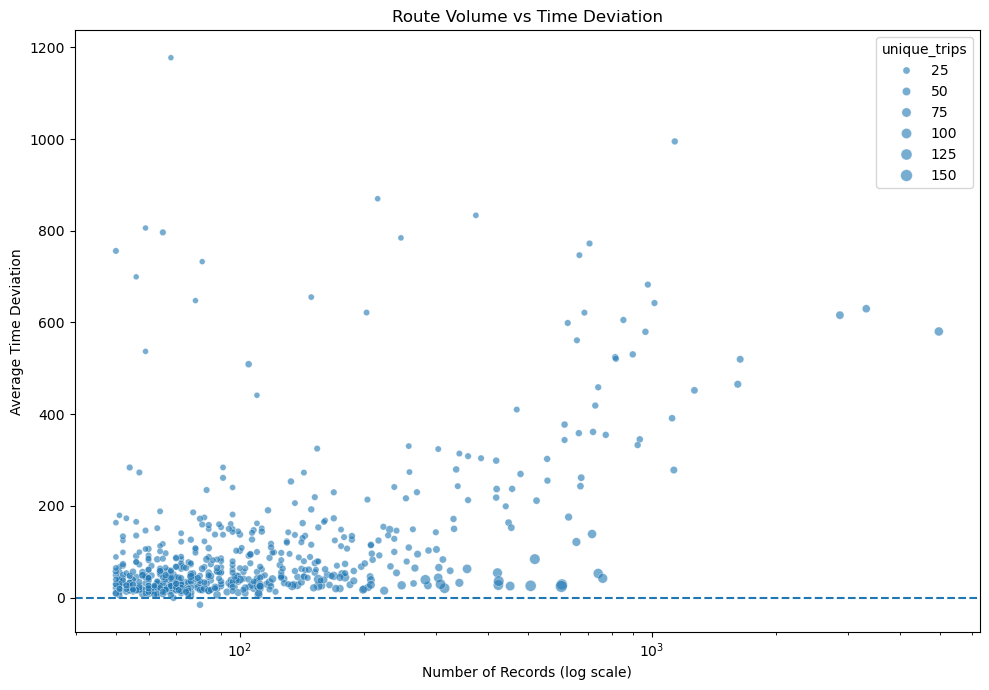

In [57]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=route_filtered,
    x="records",
    y="avg_time_deviation",
    size="unique_trips",
    alpha=0.6
)

plt.xscale("log")
plt.axhline(0, linestyle="--")

plt.title("Route Volume vs Time Deviation")
plt.xlabel("Number of Records (log scale)")
plt.ylabel("Average Time Deviation")

plt.tight_layout()
plt.show()

11. Cutoff Analysis

## 11. Cutoff Analysis

This section evaluates whether cutoff status is associated with differences in logistics performance.

The analysis compares cutoff and non-cutoff records using:

- Number of records
- Average actual travel time
- Average OSRM estimated time
- Average time deviation
- Time deviation percentage

The objective is to determine whether records associated with cutoff conditions exhibit systematically different travel-time performance.

In [58]:
cutoff_performance = (
    df.groupby("is_cutoff")
    .agg(
        records=("trip_uuid", "size"),
        unique_trips=("trip_uuid", "nunique"),
        avg_actual_time=("actual_time", "mean"),
        avg_osrm_time=("osrm_time", "mean"),
        avg_time_deviation=("time_deviation", "mean")
    )
    .reset_index()
)

cutoff_performance["time_deviation_pct"] = (
    cutoff_performance["avg_time_deviation"]
    / cutoff_performance["avg_osrm_time"]
    * 100
)

cutoff_performance.round(2)

,is_cutoff,records,unique_trips,avg_actual_time,avg_osrm_time,avg_time_deviation,time_deviation_pct
0,False,26118,14703,202.34,91.39,110.94,121.39
1,True,118749,14473,464.13,240.81,223.32,92.74


In [59]:
cutoff_performance["is_cutoff"] = (
    cutoff_performance["is_cutoff"]
    .map({
        True: "Cutoff",
        False: "Non-Cutoff"
    })
)

cutoff_performance

,is_cutoff,records,unique_trips,avg_actual_time,avg_osrm_time,avg_time_deviation,time_deviation_pct
0,Non-Cutoff,26118,14703,202.335860,91.392335,110.943526,121.392594
1,Cutoff,118749,14473,464.125441,240.805986,223.319455,92.738332


### Key Finding — Cutoff vs Non-Cutoff Performance

Cutoff records show substantially higher absolute travel-time deviations than non-cutoff records.

The average time deviation for cutoff records is 223.32 compared with 110.94 for non-cutoff records, indicating approximately twice the absolute deviation.

However, the relative time deviation is higher for non-cutoff records (121.39%) than cutoff records (92.74%). This difference occurs because cutoff records also have substantially higher baseline OSRM travel times.

Therefore, cutoff status is associated with higher absolute travel-time gaps in this dataset, but not necessarily higher relative deviation.

### Distribution of Time Deviation by Cutoff Status

The distribution of time deviation is compared between cutoff and non-cutoff records to determine whether the observed difference in averages is driven by a broad shift in performance or by a small number of extreme observations.

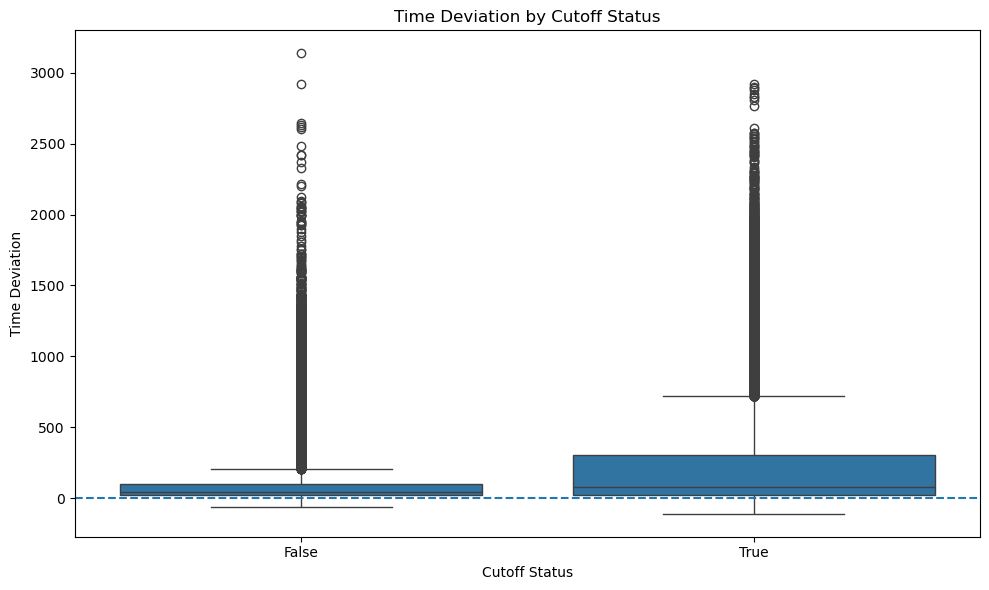

In [60]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="is_cutoff",
    y="time_deviation"
)

plt.axhline(0, linestyle="--")

plt.title("Time Deviation by Cutoff Status")
plt.xlabel("Cutoff Status")
plt.ylabel("Time Deviation")

plt.tight_layout()
plt.show()

### Interpretation — Cutoff Status

The boxplot shows that cutoff-associated records generally have higher time deviations and greater variability than non-cutoff records.

The cutoff group has a higher central tendency and a wider spread, with numerous extreme positive observations. Both groups contain outliers and some negative deviations, indicating that cutoff status does not consistently imply a delay.

The analysis identifies an association between cutoff status and travel-time deviation, but does not establish causality.

11.3 Cutoff Factor Analysis

### 11.3 Cutoff Factor vs Time Deviation

The relationship between cutoff factor and time deviation is examined to determine whether increasing cutoff factors are associated with larger travel-time deviations.

Because cutoff factor is highly right-skewed, a logarithmic x-axis is used for visualization.

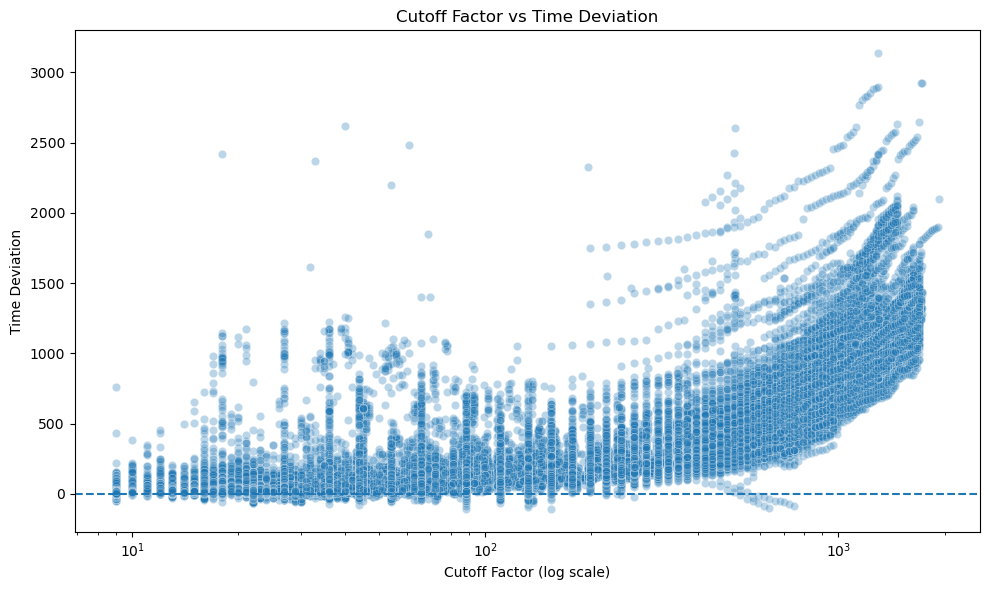

In [61]:
cutoff_factor_data = df[
    df["cutoff_factor"].notna() &
    (df["cutoff_factor"] > 0)
].copy()

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=cutoff_factor_data,
    x="cutoff_factor",
    y="time_deviation",
    alpha=0.3
)

plt.xscale("log")

plt.axhline(0, linestyle="--")

plt.title("Cutoff Factor vs Time Deviation")
plt.xlabel("Cutoff Factor (log scale)")
plt.ylabel("Time Deviation")

plt.tight_layout()
plt.show()

then calculate correlation

In [62]:
cutoff_factor_data[
    ["cutoff_factor", "time_deviation"]
].corr()

,cutoff_factor,time_deviation
cutoff_factor,1.000000,0.917381
time_deviation,0.917381,1.000000


### Key Finding — Cutoff Factor

The correlation between cutoff factor and time deviation is 0.917, indicating a very strong positive association.

Records with higher cutoff factors tend to exhibit substantially higher deviations between actual and OSRM travel times.

This suggests that cutoff-related operational conditions are strongly associated with increased travel-time deviations in the dataset. However, correlation does not establish a causal relationship.

In [63]:
cutoff_factor_data[
    ["cutoff_factor", "time_deviation"]
].corr(method="spearman")

,cutoff_factor,time_deviation
cutoff_factor,1.000000,0.881802
time_deviation,0.881802,1.000000


### Correlation Validation

Both Pearson and Spearman correlation show a very strong positive association between cutoff factor and time deviation.

- Pearson correlation: 0.917
- Spearman correlation: 0.882

The high Spearman correlation confirms that the observed relationship is not solely driven by extreme cutoff-factor values and remains strong when considering the rank-based relationship between the variables.

This indicates that higher cutoff factors are consistently associated with greater travel-time deviations in the dataset. However, this analysis establishes association rather than causation.

11.4 Final cutoff-factor analysis

In [64]:
cutoff_factor_data["cutoff_factor_group"] = pd.qcut(
    cutoff_factor_data["cutoff_factor"],
    q=4,
    labels=["Low", "Medium", "High", "Very High"]
)

cutoff_factor_summary = (
    cutoff_factor_data
    .groupby("cutoff_factor_group", observed=False)
    .agg(
        records=("trip_uuid", "size"),
        avg_cutoff_factor=("cutoff_factor", "mean"),
        avg_time_deviation=("time_deviation", "mean"),
        median_time_deviation=("time_deviation", "median")
    )
    .reset_index()
)

cutoff_factor_summary.round(2)

,cutoff_factor_group,records,avg_cutoff_factor,avg_time_deviation,median_time_deviation
0,Low,39538,16.20,22.79,15.0
1,Medium,38067,43.21,54.74,36.0
2,High,31862,155.87,143.40,120.0
3,Very High,35400,748.35,617.59,540.0


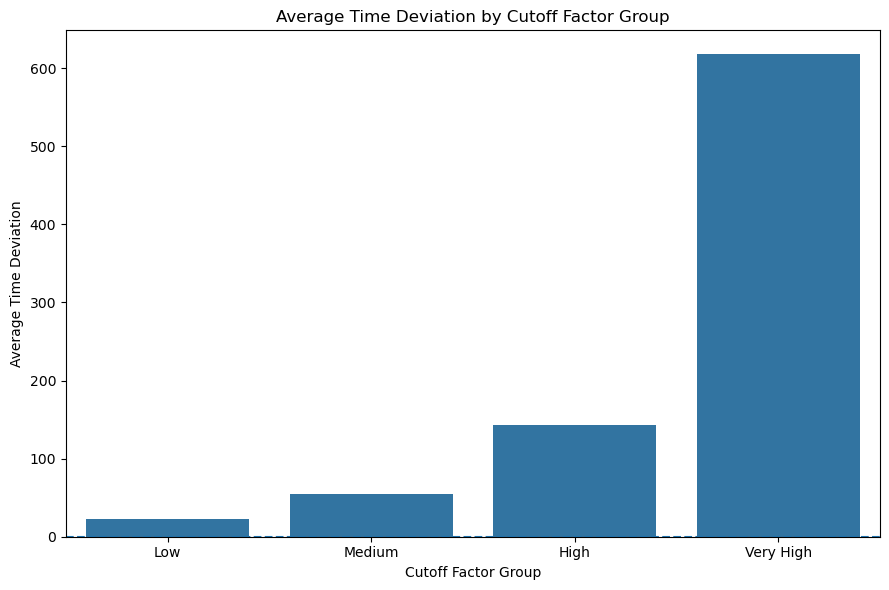

In [65]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=cutoff_factor_summary,
    x="cutoff_factor_group",
    y="avg_time_deviation"
)

plt.axhline(0, linestyle="--")

plt.title("Average Time Deviation by Cutoff Factor Group")
plt.xlabel("Cutoff Factor Group")
plt.ylabel("Average Time Deviation")

plt.tight_layout()
plt.show()

### Key Finding — Cutoff Factor Groups

Time deviation increases substantially as cutoff factor increases.

The average time deviation rises from 22.79 in the Low cutoff-factor group to 617.59 in the Very High group. The median shows the same pattern, increasing from 15.0 to 540.0.

This consistent increase across cutoff-factor groups reinforces the strong correlation identified earlier and indicates that higher cutoff-factor conditions are strongly associated with greater travel-time deviations.

The Very High cutoff-factor group has approximately 27 times the average time deviation of the Low group.

This represents an important operational signal for identifying routes with elevated delivery-time risk. The analysis shows association rather than causation.

12. Route Efficiency & Segment Performance
## 12. Route Efficiency & Segment Performance

The `factor` variable is examined to understand the relationship between actual and estimated route performance.

Segment-level metrics are also analyzed to identify whether inefficiencies are concentrated in specific parts of a route.

In [66]:
df["factor"].describe()

count    144867.000000
mean          2.120107
std           1.715421
min           0.144000
25%           1.604264
50%           1.857143
75%           2.213483
max          77.387097
Name: factor, dtype: float64

checking missing values

In [67]:
df["factor"].isna().sum()

np.int64(0)

And check unusual values:

In [68]:
print("Factor <= 0:", (df["factor"] <= 0).sum())
print("Factor = 1:", (df["factor"] == 1).sum())
print("Factor > 1:", (df["factor"] > 1).sum())

Factor <= 0: 0
Factor = 1: 552
Factor > 1: 141745


Also check the relationship with time deviation

In [69]:
df[["factor", "time_deviation"]].corr()

,factor,time_deviation
factor,1.000000,0.136014
time_deviation,0.136014,1.000000


12.2 Segment Factor

In [70]:
df["segment_factor"].describe()

count    144867.000000
mean          2.218368
std           4.847530
min         -23.444444
25%           1.347826
50%           1.684211
75%           2.250000
max         574.250000
Name: segment_factor, dtype: float64

In [71]:
print("Missing segment_factor:", df["segment_factor"].isna().sum())
print("Segment factor <= 0:", (df["segment_factor"] <= 0).sum())
print("Segment factor = 1:", (df["segment_factor"] == 1).sum())
print("Segment factor > 1:", (df["segment_factor"] > 1).sum())

Missing segment_factor: 0
Segment factor <= 0: 2600
Segment factor = 1: 2371
Segment factor > 1: 129351


In [72]:
df[["segment_factor", "segment_actual_time"]].corr()

,segment_factor,segment_actual_time
segment_factor,1.000000,0.483864
segment_actual_time,0.483864,1.000000


### Factor Analysis — Key Finding

The route-level `factor` variable contains no non-positive values. Most observations have a factor greater than 1, while only a small number of records have a factor exactly equal to 1.

The correlation between `factor` and `time_deviation` is 0.136, indicating only a weak positive association.

Therefore, route-level factor alone does not appear to be a strong predictor of travel-time deviation in this dataset. This contrasts with the much stronger relationship observed between `cutoff_factor` and time deviation.

12.2 Now analyze segment_factor

In [73]:
df["segment_factor"].describe()

count    144867.000000
mean          2.218368
std           4.847530
min         -23.444444
25%           1.347826
50%           1.684211
75%           2.250000
max         574.250000
Name: segment_factor, dtype: float64

In [74]:
print("Missing segment_factor:", df["segment_factor"].isna().sum())
print("Segment factor <= 0:", (df["segment_factor"] <= 0).sum())
print("Segment factor = 1:", (df["segment_factor"] == 1).sum())
print("Segment factor > 1:", (df["segment_factor"] > 1).sum())

Missing segment_factor: 0
Segment factor <= 0: 2600
Segment factor = 1: 2371
Segment factor > 1: 129351


In [75]:
df[["segment_factor", "segment_actual_time"]].corr()

,segment_factor,segment_actual_time
segment_factor,1.000000,0.483864
segment_actual_time,0.483864,1.000000


### Segment Factor Analysis — Key Finding

The `segment_factor` variable has no missing values and a median of 1.68. Most observations (129,351 records) have a segment factor greater than 1.

The correlation between `segment_factor` and `segment_actual_time` is 0.484, indicating a moderate positive association. This is substantially stronger than the relationship observed for the route-level `factor`.

However, 2,600 observations have non-positive segment-factor values and the variable contains extreme values, with a maximum of 574.25. These observations require additional validation before drawing conclusions from the raw factor distribution.

In [76]:
segment_factor_clean = df[
    (df["segment_factor"] > 0) &
    (df["segment_factor"] < df["segment_factor"].quantile(0.99))
].copy()

print("Original records:", len(df))
print("Filtered records:", len(segment_factor_clean))

Original records: 144867
Filtered records: 140816


In [77]:
segment_factor_clean[
    ["segment_factor", "segment_actual_time"]
].corr()

,segment_factor,segment_actual_time
segment_factor,1.000000,0.424512
segment_actual_time,0.424512,1.000000


### Robust Segment Factor Finding

The initial correlation between `segment_factor` and `segment_actual_time` was 0.484.

After excluding non-positive values and the upper 1% of extreme segment-factor observations, the correlation remained moderately positive at 0.425.

The persistence of this relationship indicates that the association is not solely driven by extreme observations.

Therefore, `segment_factor` provides a useful indicator of segment-level performance, although its relationship with actual segment time is moderate rather than strong.

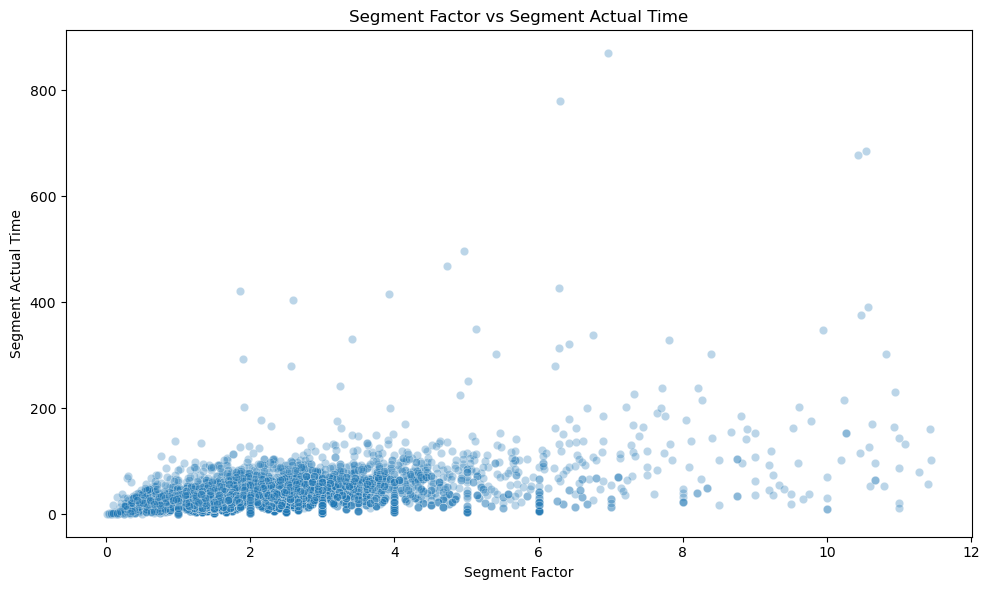

In [78]:
# Use the cleaned dataset we just created:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=segment_factor_clean.sample(
        min(10000, len(segment_factor_clean)),
        random_state=42
    ),
    x="segment_factor",
    y="segment_actual_time",
    alpha=0.3
)

plt.title("Segment Factor vs Segment Actual Time")
plt.xlabel("Segment Factor")
plt.ylabel("Segment Actual Time")

plt.tight_layout()
plt.show()

13. Delay / Risk Analysis

13.1 Define delay severity
## 13. Delay & Risk Analysis

This section identifies routes and operational patterns associated with significant travel-time deviations.

Delay severity is classified using time deviation to distinguish normal variation from potentially high-risk logistics performance.

In [79]:
df["delay_severity"] = pd.cut(
    df["time_deviation"],
    bins=[-float("inf"), 0, 30, 120, 300, float("inf")],
    labels=[
        "Ahead of Estimate",
        "Low Delay",
        "Moderate Delay",
        "High Delay",
        "Severe Delay"
    ]
)

df["delay_severity"].value_counts().sort_index()

delay_severity
Ahead of Estimate     3122
Low Delay            44881
Moderate Delay       42606
High Delay           22447
Severe Delay         31811
Name: count, dtype: int64

### Key Finding — Delay Severity

The delay-severity classification shows that 37.5% of records fall into the High or Severe Delay categories.

Approximately 22.0% of records are classified as Severe Delay, while 15.5% are classified as High Delay.

Only 2.2% of records have actual travel times below the OSRM estimate.

This indicates that substantial travel-time deviations are common in the dataset and represent an important area for logistics performance improvement.

Delay Severity by Route Type

In [80]:
delay_route_type = (
    pd.crosstab(
        df["route_type"],
        df["delay_severity"],
        normalize="index"
    ) * 100
)

delay_route_type.round(2)

delay_severity,Ahead of Estimate,Low Delay,Moderate Delay,High Delay,Severe Delay
route_type,,,,,
Carting,3.71,58.73,31.92,4.71,0.93
FTL,1.45,18.39,28.27,20.39,31.50


In [81]:
delay_route_counts = pd.crosstab(
    df["route_type"],
    df["delay_severity"]
)

delay_route_counts

delay_severity,Ahead of Estimate,Low Delay,Moderate Delay,High Delay,Severe Delay
route_type,,,,,
Carting,1679,26550,14428,2130,420
FTL,1443,18331,28178,20317,31391


### Key Finding — Route Type Delay Risk

FTL routes show substantially higher delay risk than Carting routes.

Approximately 51.89% of FTL records fall into the High or Severe Delay categories, compared with only 5.64% of Carting records.

The difference is particularly pronounced in the Severe Delay category, where 31.50% of FTL records are classified as severe compared with only 0.93% for Carting.

This indicates that FTL operations represent a significantly higher travel-time risk segment in the dataset and should be prioritized for further operational investigation.

In [82]:
route_risk = (
    df.groupby(
        ["source_center", "source_name",
         "destination_center", "destination_name"]
    )
    .agg(
        records=("trip_uuid", "size"),
        unique_trips=("trip_uuid", "nunique"),
        avg_time_deviation=("time_deviation", "mean"),
        avg_actual_time=("actual_time", "mean"),
        avg_osrm_time=("osrm_time", "mean"),
        high_severe_records=(
            "delay_severity",
            lambda x: x.isin(["High Delay", "Severe Delay"]).sum()
        )
    )
    .reset_index()
)

route_risk["high_severe_pct"] = (
    route_risk["high_severe_records"]
    / route_risk["records"]
    * 100
)

route_risk = route_risk[
    route_risk["records"] >= 50
].sort_values(
    "high_severe_pct",
    ascending=False
)

route_risk.head(15).round(2)

,source_center,source_name,destination_center,destination_name,records,unique_trips,avg_time_deviation,avg_actual_time,avg_osrm_time,high_severe_records,high_severe_pct
119,IND110037AAM,Delhi_Airport_H (Delhi),IND781018AAB,Guwahati_Hub (Assam),68,1,1177.47,1861.87,684.40,67,98.53
2511,IND781018AAB,Guwahati_Hub (Assam),IND110037AAM,Delhi_Airport_H (Delhi),1137,17,994.83,1661.67,666.83,1102,96.92
1786,IND562132AAA,Bangalore_Nelmngla_H (Karnataka),IND712311AAA,Kolkata_Dankuni_HB (West Bengal),216,3,869.86,1549.17,679.31,209,96.76
118,IND110037AAM,Delhi_Airport_H (Delhi),IND421302AAG,Bhiwandi_Mankoli_HB (Maharashtra),815,18,524.33,1048.68,524.35,786,96.44
1144,IND421302AAG,Bhiwandi_Mankoli_HB (Maharashtra),IND110037AAM,Delhi_Airport_H (Delhi),965,19,579.68,1089.86,510.18,930,96.37
2436,IND751002AAB,Bhubaneshwar_Hub (Orissa),IND562132AAA,Bangalore_Nelmngla_H (Karnataka),706,13,772.27,1347.54,575.27,676,95.75
1760,IND562132AAA,Bangalore_Nelmngla_H (Karnataka),IND462022AAA,Bhopal_Trnsport_H (Madhya Pradesh),625,13,598.92,1127.54,528.62,596,95.36
355,IND160002AAC,Chandigarh_Mehmdpur_H (Punjab),IND421302AAG,Bhiwandi_Mankoli_HB (Maharashtra),59,1,806.07,1401.47,595.41,56,94.92
64,IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),IND834002AAB,Ranchi_Hub (Jharkhand),729,16,418.79,865.68,446.89,673,92.32
60,IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),IND600056AAB,MAA_Poonamallee_HB (Tamil Nadu),1015,14,642.44,1457.12,814.68,934,92.02


### Key Finding — High-Risk Routes

Several source-to-destination routes exhibit extremely high delay risk, with more than 90% of records classified as High or Severe Delay.

The Guwahati–Delhi route shows a 96.92% High/Severe delay rate across 1,137 records, while Delhi–Bhiwandi and Bhiwandi–Delhi show rates of 96.44% and 96.37% across 815 and 965 records respectively.

Other major high-risk corridors include Bhubaneshwar–Bangalore (95.75%), Bangalore–Bhopal (95.36%), and Gurgaon–Chennai (92.02%).

These high-volume routes should be prioritized for operational investigation because their high delay rates are supported by substantial numbers of observations rather than isolated records.

In [83]:
robust_route_risk = route_risk[
    route_risk["unique_trips"] >= 5
].sort_values(
    "high_severe_pct",
    ascending=False
)

robust_route_risk.head(15).round(2)

,source_center,source_name,destination_center,destination_name,records,unique_trips,avg_time_deviation,avg_actual_time,avg_osrm_time,high_severe_records,high_severe_pct
2511,IND781018AAB,Guwahati_Hub (Assam),IND110037AAM,Delhi_Airport_H (Delhi),1137,17,994.83,1661.67,666.83,1102,96.92
118,IND110037AAM,Delhi_Airport_H (Delhi),IND421302AAG,Bhiwandi_Mankoli_HB (Maharashtra),815,18,524.33,1048.68,524.35,786,96.44
1144,IND421302AAG,Bhiwandi_Mankoli_HB (Maharashtra),IND110037AAM,Delhi_Airport_H (Delhi),965,19,579.68,1089.86,510.18,930,96.37
2436,IND751002AAB,Bhubaneshwar_Hub (Orissa),IND562132AAA,Bangalore_Nelmngla_H (Karnataka),706,13,772.27,1347.54,575.27,676,95.75
1760,IND562132AAA,Bangalore_Nelmngla_H (Karnataka),IND462022AAA,Bhopal_Trnsport_H (Madhya Pradesh),625,13,598.92,1127.54,528.62,596,95.36
64,IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),IND834002AAB,Ranchi_Hub (Jharkhand),729,16,418.79,865.68,446.89,673,92.32
60,IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),IND600056AAB,MAA_Poonamallee_HB (Tamil Nadu),1015,14,642.44,1457.12,814.68,934,92.02
2275,IND712311AAA,Kolkata_Dankuni_HB (West Bengal),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),658,11,561.13,1113.35,552.22,593,90.12
2276,IND712311AAA,Kolkata_Dankuni_HB (West Bengal),IND421302AAG,Bhiwandi_Mankoli_HB (Maharashtra),374,5,833.65,1531.10,697.46,337,90.11
58,IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),IND521225AAB,Vijayawada_Rynapadu_H (Andhra Pradesh),686,11,621.38,1284.62,663.24,615,89.65


### Key Finding — High-Confidence Route Risk

After requiring a minimum of five unique trips, several major logistics corridors continue to show exceptionally high High/Severe Delay rates.

Guwahati–Delhi has a 96.92% High/Severe delay rate across 1,137 records, while Delhi–Bhiwandi and Bhiwandi–Delhi show rates of 96.44% and 96.37%.

The Gurgaon–Bangalore corridor is particularly important because it combines high operational volume (4,976 records across 66 trips) with an 88.38% High/Severe delay rate. Its average actual travel time is 1,367.21 compared with an OSRM estimate of 786.83, resulting in an average deviation of 580.38.

These corridors represent priority candidates for operational investigation and route-level performance improvement.

14.1 Route Type × Cutoff Status

In [84]:
combined_risk = (
    df.groupby(["route_type", "is_cutoff"])
    .agg(
        records=("trip_uuid", "size"),
        unique_trips=("trip_uuid", "nunique"),
        avg_actual_time=("actual_time", "mean"),
        avg_osrm_time=("osrm_time", "mean"),
        avg_time_deviation=("time_deviation", "mean"),
        avg_time_deviation_pct=("time_deviation_pct", "mean")
    )
    .reset_index()
)

combined_risk

KeyError: "Column(s) ['time_deviation_pct'] do not exist"

Step 1 — Create time_deviation_pct

In [ ]:
df["time_deviation_pct"] = (
    df["time_deviation"] / df["osrm_time"]
) * 100

Step 2 — Run the combined analysis again

In [ ]:
combined_risk = (
    df.groupby(["route_type", "is_cutoff"])
    .agg(
        records=("trip_uuid", "size"),
        unique_trips=("trip_uuid", "nunique"),
        avg_actual_time=("actual_time", "mean"),
        avg_osrm_time=("osrm_time", "mean"),
        avg_time_deviation=("time_deviation", "mean"),
        avg_time_deviation_pct=("time_deviation_pct", "mean")
    )
    .reset_index()
)

combined_risk.round(2)

,route_type,is_cutoff,records,unique_trips,avg_actual_time,avg_osrm_time,avg_time_deviation,avg_time_deviation_pct
0,Carting,False,12305,8801,90.76,34.20,56.56,187.73
1,Carting,True,32902,8674,63.11,29.05,34.07,123.50
2,FTL,False,13813,5902,301.73,142.34,159.39,128.52
3,FTL,True,85847,5799,617.82,321.97,295.85,94.10


Step 3 — Calculate High + Severe risk

In [ ]:
risk_combo = (
    df.assign(
        high_severe=df["delay_severity"].isin(
            ["High Delay", "Severe Delay"]
        )
    )
    .groupby(["route_type", "is_cutoff"])
    .agg(
        records=("trip_uuid", "size"),
        high_severe_records=("high_severe", "sum")
    )
    .reset_index()
)

risk_combo["high_severe_pct"] = (
    risk_combo["high_severe_records"]
    / risk_combo["records"]
    * 100
)

risk_combo.round(2)

,route_type,is_cutoff,records,high_severe_records,high_severe_pct
0,Carting,False,12305,1158,9.41
1,Carting,True,32902,1392,4.23
2,FTL,False,13813,4037,29.23
3,FTL,True,85847,47671,55.53


## 14.1 Combined Route Type and Cutoff Risk

The combined analysis shows that FTL operations under cutoff conditions represent the highest observed delivery-risk segment.

FTL + Cutoff records have a High/Severe Delay rate of 55.53%, compared with 29.23% for FTL + Non-Cutoff records.

The difference is even more pronounced when compared with Carting, where the High/Severe Delay rates are 9.41% for Non-Cutoff and 4.23% for Cutoff records.

FTL + Cutoff records also have the highest average time deviation at 295.85, compared with 159.39 for FTL + Non-Cutoff records.

These results indicate that FTL operations associated with cutoff conditions should be prioritized for further investigation and operational improvement.

14.2 One final analysis

In [ ]:
cutoff_risk = (
    df.groupby("cutoff_factor_group")
    .agg(
        records=("trip_uuid", "size"),
        unique_trips=("trip_uuid", "nunique"),
        avg_cutoff_factor=("cutoff_factor", "mean"),
        avg_time_deviation=("time_deviation", "mean"),
        median_time_deviation=("time_deviation", "median"),
        high_severe_records=(
            "delay_severity",
            lambda x: x.isin(
                ["High Delay", "Severe Delay"]
            ).sum()
        )
    )
    .reset_index()
)

cutoff_risk["high_severe_pct"] = (
    cutoff_risk["high_severe_records"]
    / cutoff_risk["records"]
    * 100
)

cutoff_risk.round(2)

KeyError: 'cutoff_factor_group'

In [ ]:
# Step 1 — Create the cutoff-factor groups
df["cutoff_factor_group"] = pd.cut(
    df["cutoff_factor"],
    bins=[-float("inf"), 25, 100, 250, float("inf")],
    labels=["Low", "Medium", "High", "Very High"]
)

In [ ]:
#verify
df["cutoff_factor_group"].value_counts().sort_index()

cutoff_factor_group
Low          41098
Medium       44318
High         20767
Very High    38684
Name: count, dtype: int64

In [ ]:
cutoff_risk = (
    df.groupby("cutoff_factor_group", observed=False)
    .agg(
        records=("trip_uuid", "size"),
        unique_trips=("trip_uuid", "nunique"),
        avg_cutoff_factor=("cutoff_factor", "mean"),
        avg_time_deviation=("time_deviation", "mean"),
        median_time_deviation=("time_deviation", "median"),
        high_severe_records=(
            "delay_severity",
            lambda x: x.isin(
                ["High Delay", "Severe Delay"]
            ).sum()
        )
    )
    .reset_index()
)

cutoff_risk["high_severe_pct"] = (
    cutoff_risk["high_severe_records"]
    / cutoff_risk["records"]
    * 100
)

cutoff_risk.round(2)

,cutoff_factor_group,records,unique_trips,avg_cutoff_factor,avg_time_deviation,median_time_deviation,high_severe_records,high_severe_pct
0,Low,41098,14688,16.50,23.18,15.0,599,1.46
1,Medium,44318,9911,51.20,63.48,42.0,4145,9.35
2,High,20767,3149,164.01,146.16,126.0,11110,53.50
3,Very High,38684,1466,708.05,584.62,499.0,38404,99.28


In [ ]:
df["cutoff_factor"].describe()

count    144867.000000
mean        232.926567
std         344.755577
min           9.000000
25%          22.000000
50%          66.000000
75%         286.000000
max        1927.000000
Name: cutoff_factor, dtype: float64

In [ ]:
df["cutoff_factor_group"].value_counts().sort_index()

cutoff_factor_group
Low          41098
Medium       44318
High         20767
Very High    38684
Name: count, dtype: int64